# Data Mining Analyzer

In [1]:
from src.eda import correlate_features, scatter_plot_features, \
    line_plot_features
from src.enums import prefixes, keys
from src.serialize import get_files, load_from_file
from src.transform import transform, Transformation

print("Available training folds:")
for training_fold in get_files(prefixes['04_03_data_mining_folds_']):
    print(training_fold)

Available training folds:
04_03_data_mining_folds_0
04_03_data_mining_folds_1
04_03_data_mining_folds_2
04_03_data_mining_folds_3
04_03_data_mining_folds_4


In [2]:
training_fold = "04_03_data_mining_folds_0"

df = transform(
    load_from_file(training_fold),
    # Keep in sync with 04-03-data-mining.ipynb.
    {
        keys['nitrogen_dioxide (μg/m³)']: Transformation.SQRT,
        keys['carbon_monoxide (μg/m³)']: Transformation.LOG1P,
    }
)

## Correlate  features

Identify which features move together.

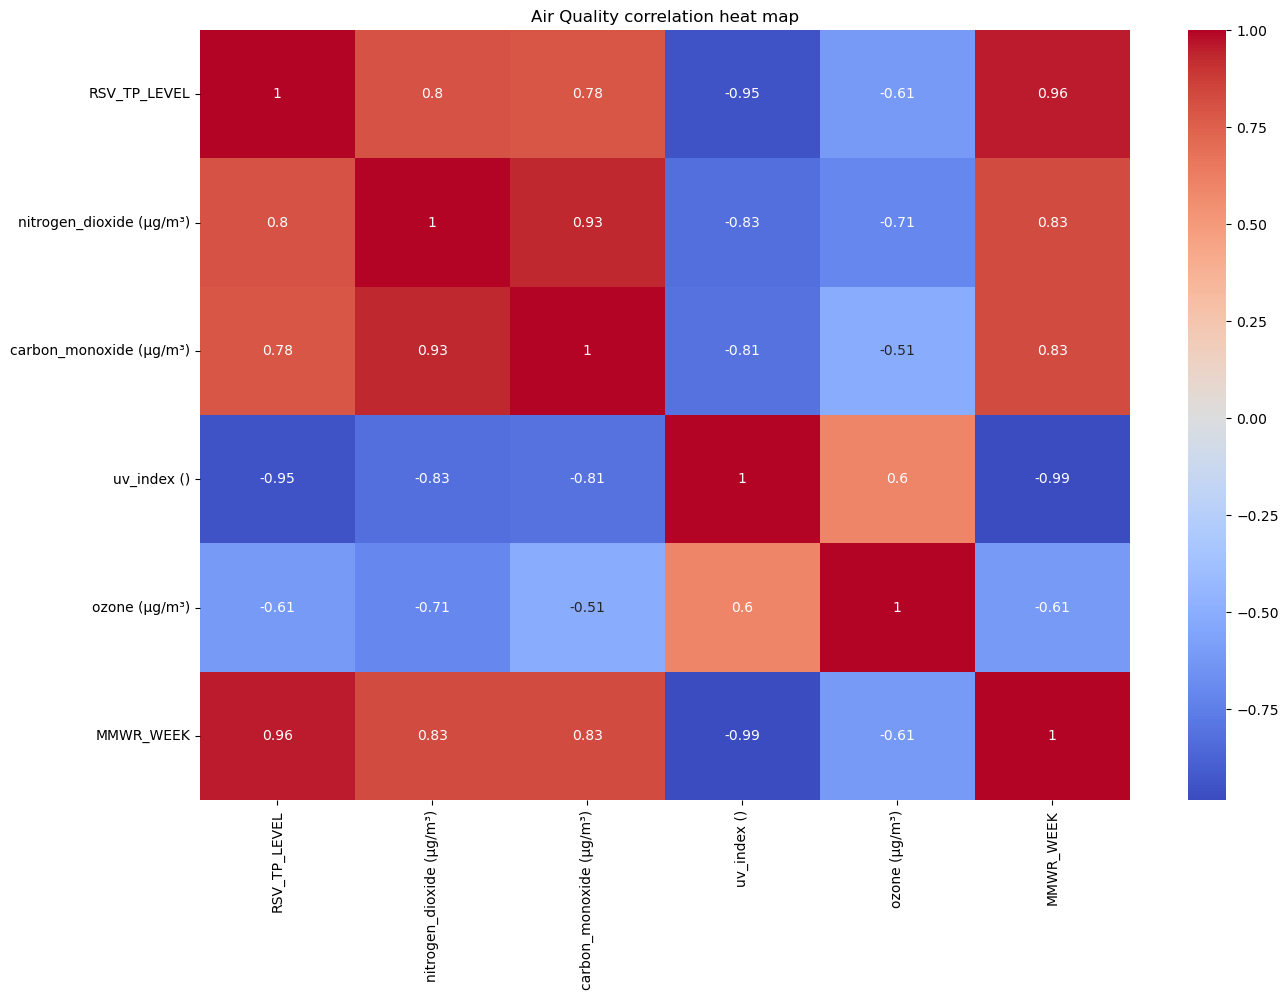

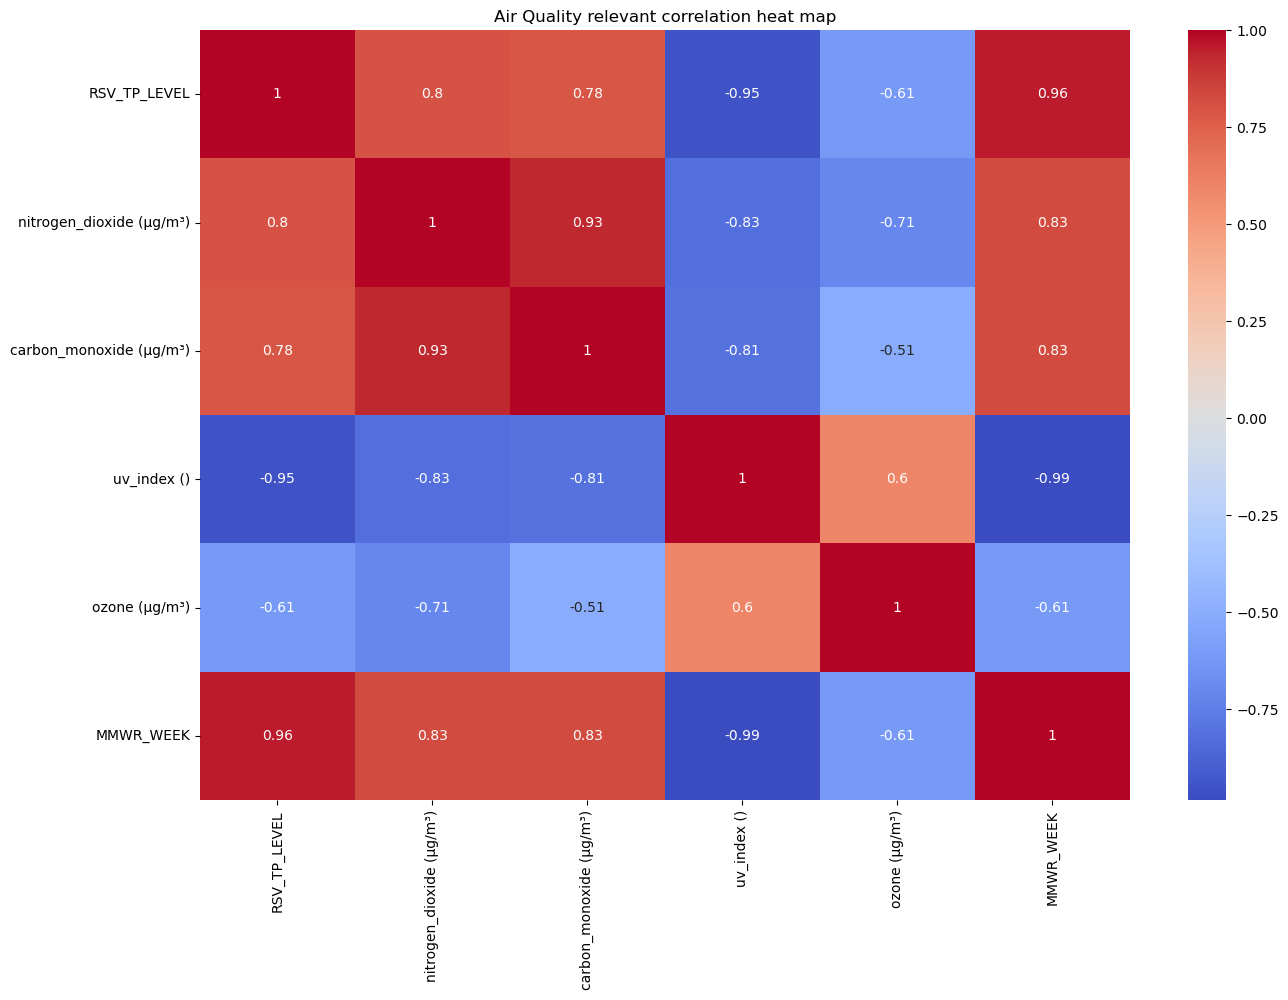

In [3]:
df_corr = df.copy()
correlate_features(df_corr, relevance=0.5)

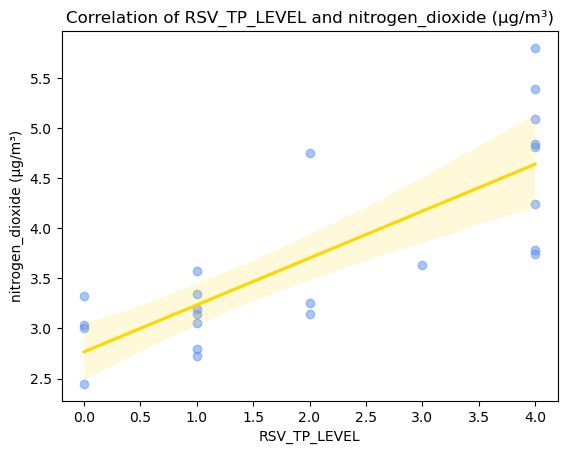

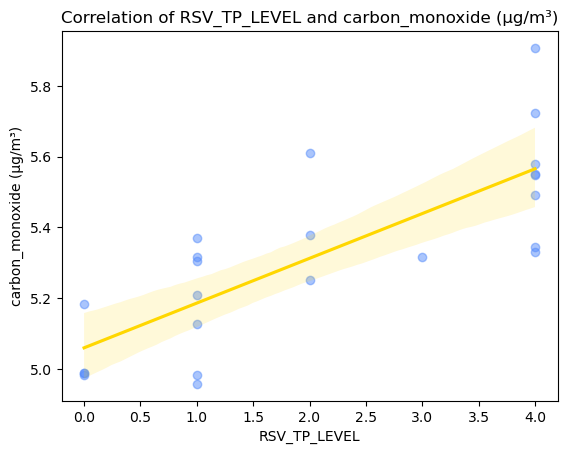

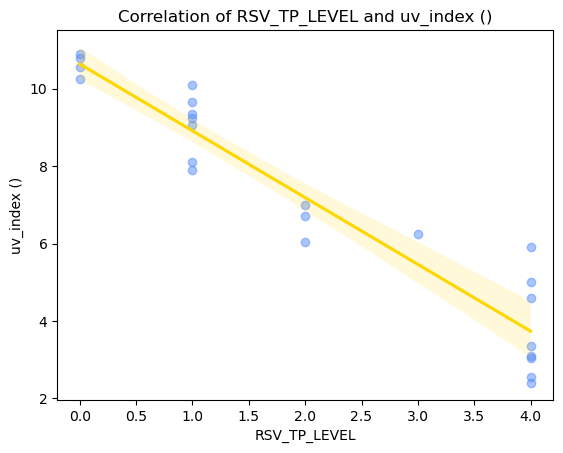

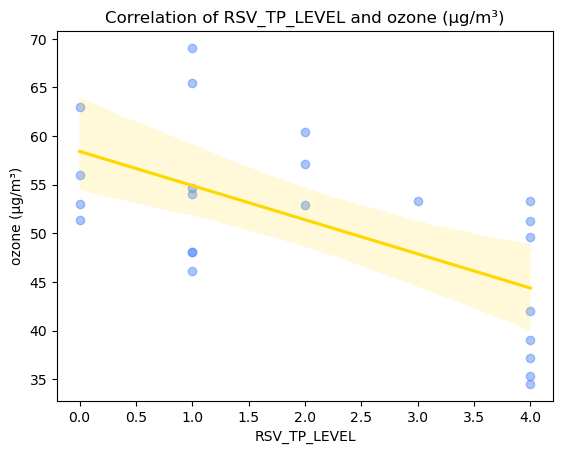

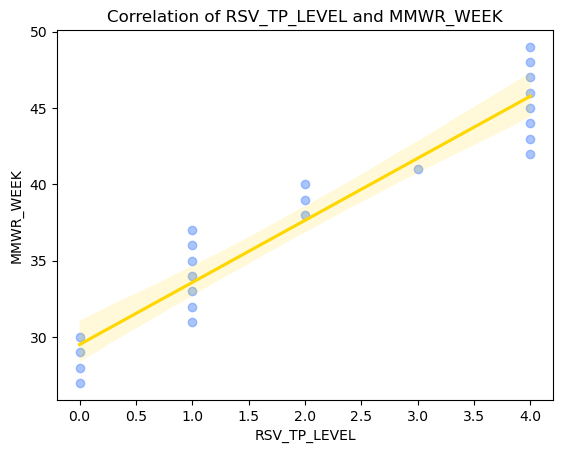

In [4]:
correlations = [
    [keys['RSV_TP_LEVEL'], keys['nitrogen_dioxide (μg/m³)']],
    [keys['RSV_TP_LEVEL'], keys['carbon_monoxide (μg/m³)']],
    [keys['RSV_TP_LEVEL'], keys['uv_index ()']],
    [keys['RSV_TP_LEVEL'], keys['ozone (μg/m³)']],
    [keys['RSV_TP_LEVEL'], keys['MMWR_WEEK']],
]

scatter_plot_features(df_corr, correlations)

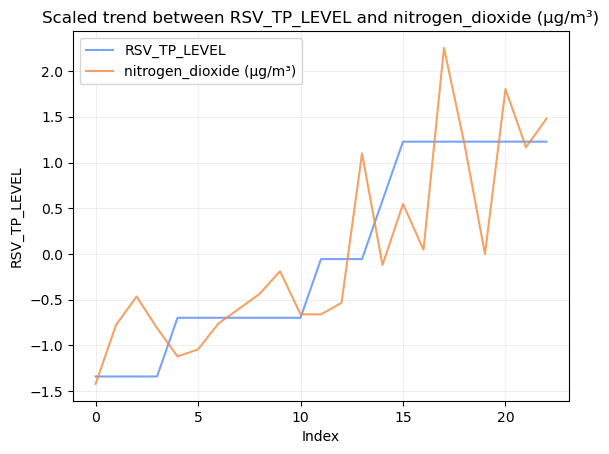

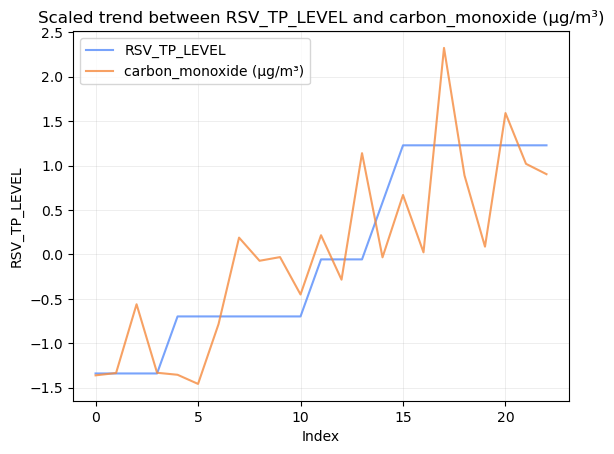

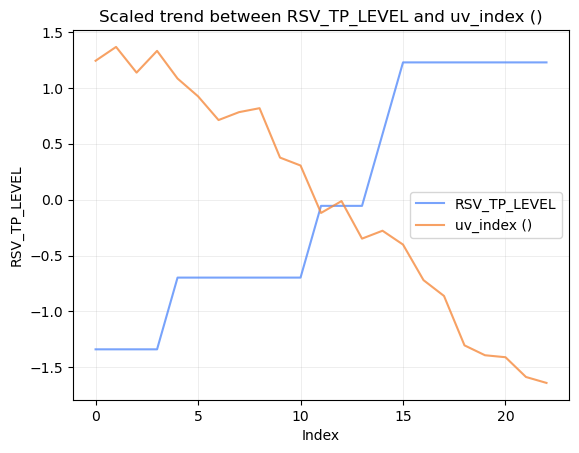

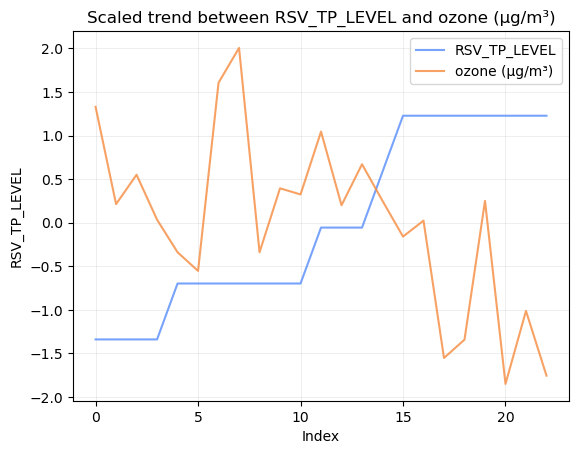

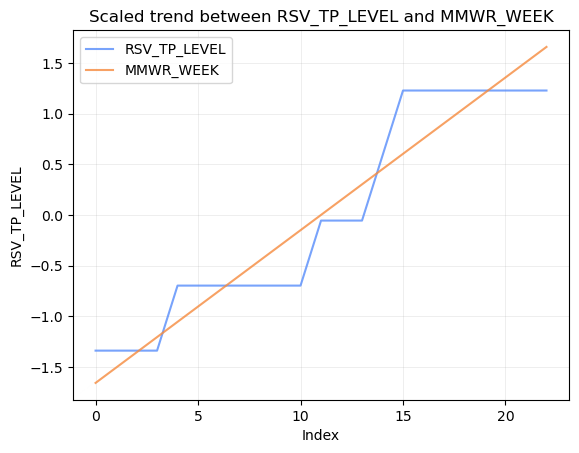

In [5]:
line_plot_features(df_corr, correlations)